# Customer Churn Prediction

Churn prediction with preprocessing, XGBoost, evaluation, and SHAP.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd 

df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)
print(df['Churn'].value_counts(normalize=True))

(7043, 21)
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


## Data preview

Load the dataset and inspect the number of rows and the initial class balance for churn.

In [2]:
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


## Summary stats

Review summary statistics for numerical and categorical columns to understand data quality and feature ranges.

In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Structure and missing values

Inspect data types and identify any missing values before cleaning.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Churn balance

Visualize the churn distribution and verify the target imbalance.

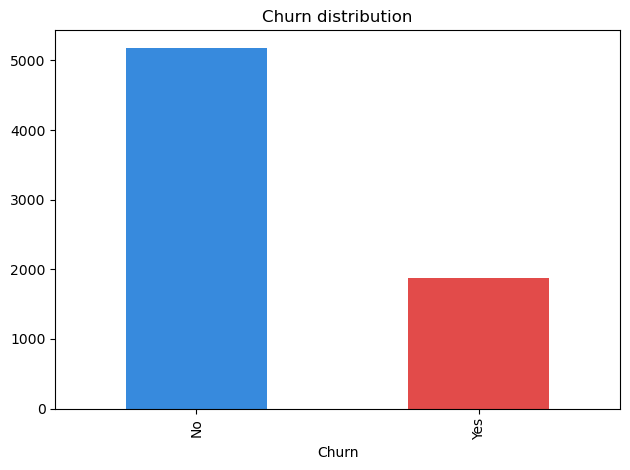

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

df['Churn'].value_counts().plot(kind='bar', color=['#378ADD','#E24B4A'])
plt.title('Churn distribution')
plt.tight_layout()

## Categorical features

Explore how churn varies by contract type, internet service, payment method, and tech support.

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

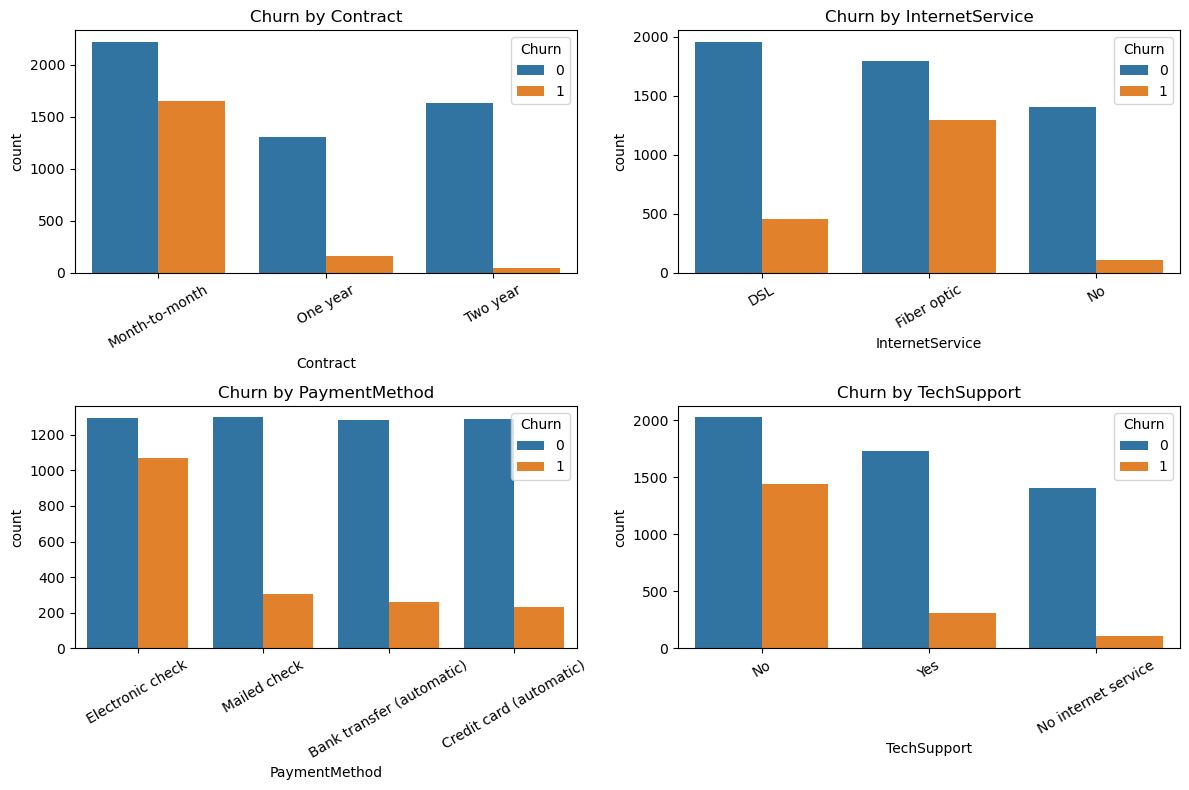

In [7]:
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), cat_cols):
    sns.countplot(data=df, x=col, hue='Churn', ax=ax)
    ax.set_title(f'Churn by {col}')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()

## Correlation

Check numeric feature relationships and identify possible redundant features.

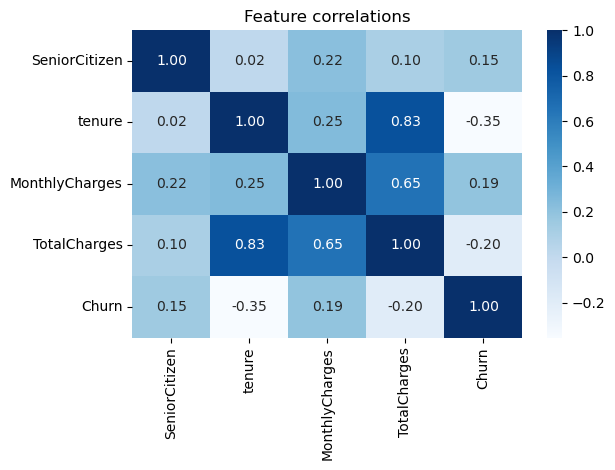

In [8]:
num_df = df.select_dtypes(include='number')
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='Blues')
plt.title('Feature correlations')
plt.tight_layout()

## Preprocessing

Prepare the dataset with scaling for numeric features and one-hot encoding for categorical features.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

df.drop(columns=['customerID'], inplace=True)

X = df.drop('Churn', axis=1)
y = df['Churn']

cat_features = X.select_dtypes(include='object').columns.tolist()
num_features = X.select_dtypes(include='number').columns.tolist()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Imbalance handling

Apply SMOTE to balance the training set and improve model learning on churn examples.

In [10]:
from imblearn.over_sampling import SMOTE

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_proc, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", dict(zip(*[['0','1'], [sum(y_train_res==0), sum(y_train_res==1)]])))

Before SMOTE: {0: 4130, 1: 1495}
After SMOTE:  {'0': 4130, '1': 4130}


## Training

Train an XGBoost classifier and evaluate it on the test set.

              precision    recall  f1-score   support

           0       0.88      0.75      0.81      1033
           1       0.51      0.73      0.60       374

    accuracy                           0.74      1407
   macro avg       0.70      0.74      0.70      1407
weighted avg       0.78      0.74      0.75      1407

ROC-AUC: 0.811


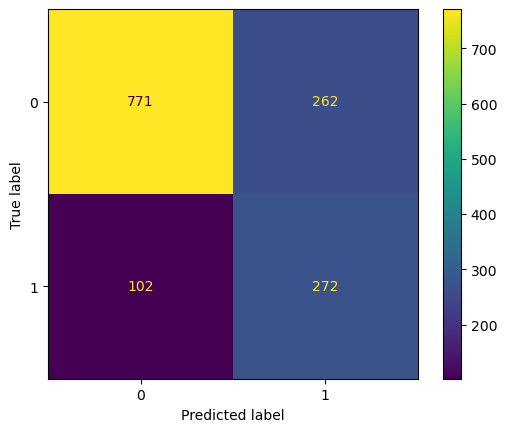

In [11]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay

model = XGBClassifier(
    scale_pos_weight=3,   
    eval_metric='logloss',
    random_state=42
)
model.fit(X_train_res, y_train_res)

y_pred  = model.predict(X_test_proc)
y_proba = model.predict_proba(X_test_proc)[:, 1]

print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)


## Threshold tuning

Explore precision and recall across probability thresholds and choose a decision threshold.

              precision    recall  f1-score   support

           0       0.88      0.72      0.79      1033
           1       0.49      0.74      0.59       374

    accuracy                           0.73      1407
   macro avg       0.69      0.73      0.69      1407
weighted avg       0.78      0.73      0.74      1407



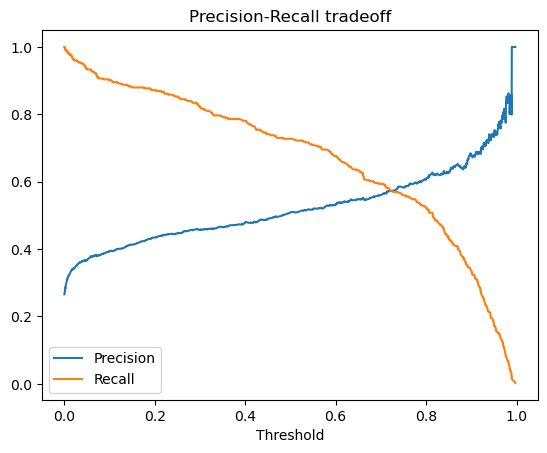

In [12]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.title('Precision-Recall tradeoff')

y_pred_tuned = (y_proba >= 0.45).astype(int)
print(classification_report(y_test, y_pred_tuned))

## SHAP

Use SHAP values to understand which features drive churn predictions.

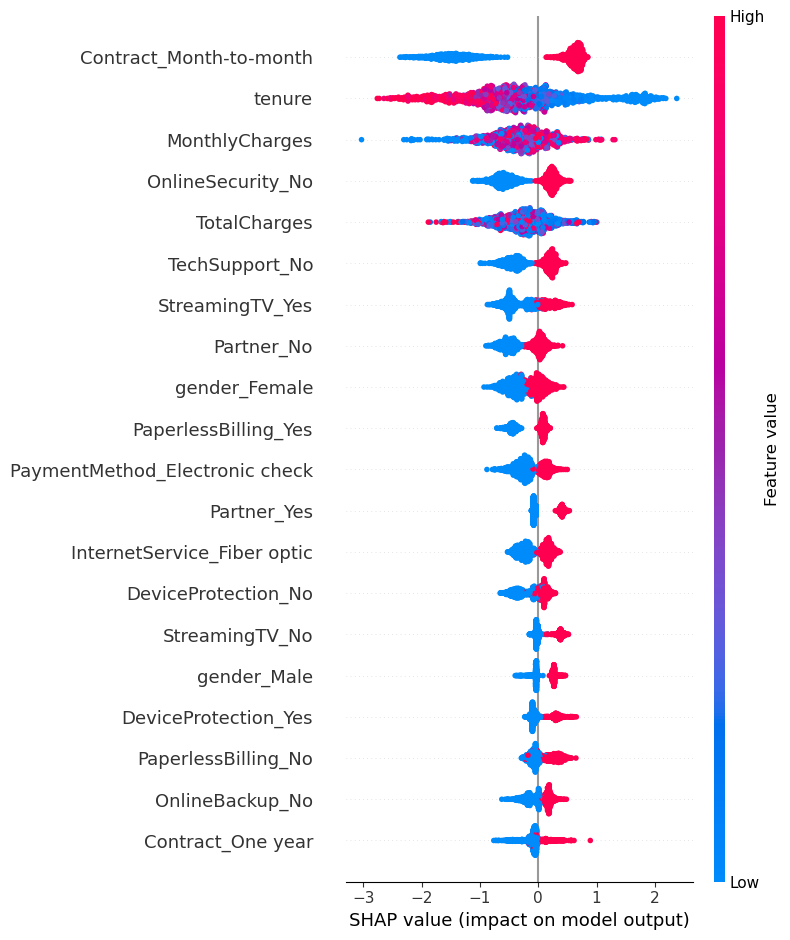

In [13]:
import shap

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_proc)

feature_names = (
    num_features +
    preprocessor.named_transformers_['cat']
                 .get_feature_names_out(cat_features).tolist()
)

shap.summary_plot(shap_values, X_test_proc, feature_names=feature_names, show=False)
plt.tight_layout()